<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/FDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📐 MALHA: 4 x 4 = 16 pontos totais
📍 Pontos internos: 2 x 2 = 4

🔧 Resolvendo abordagem 1 (sistema completo)...
🔧 Resolvendo abordagem 2 (sistema reduzido)...

🎨 Gerando visualizações das matrizes em quadradinhos...


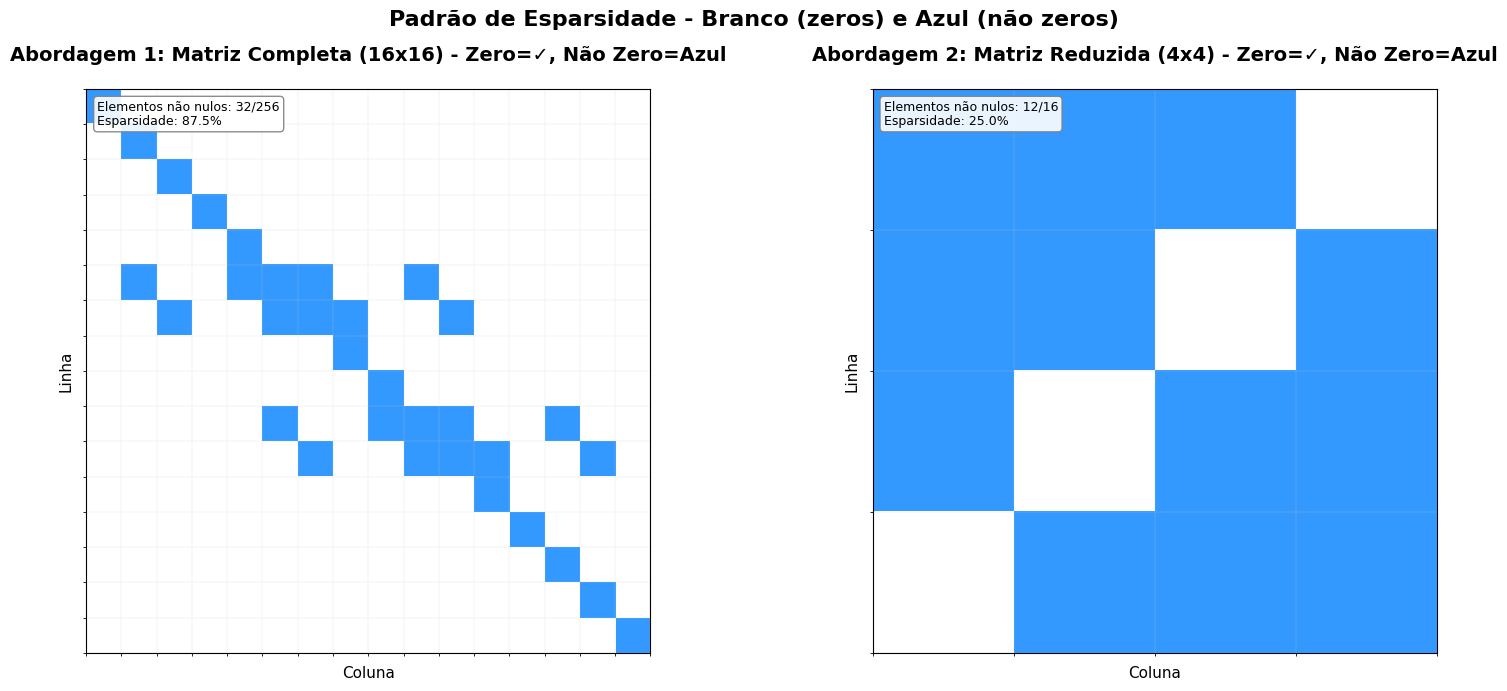

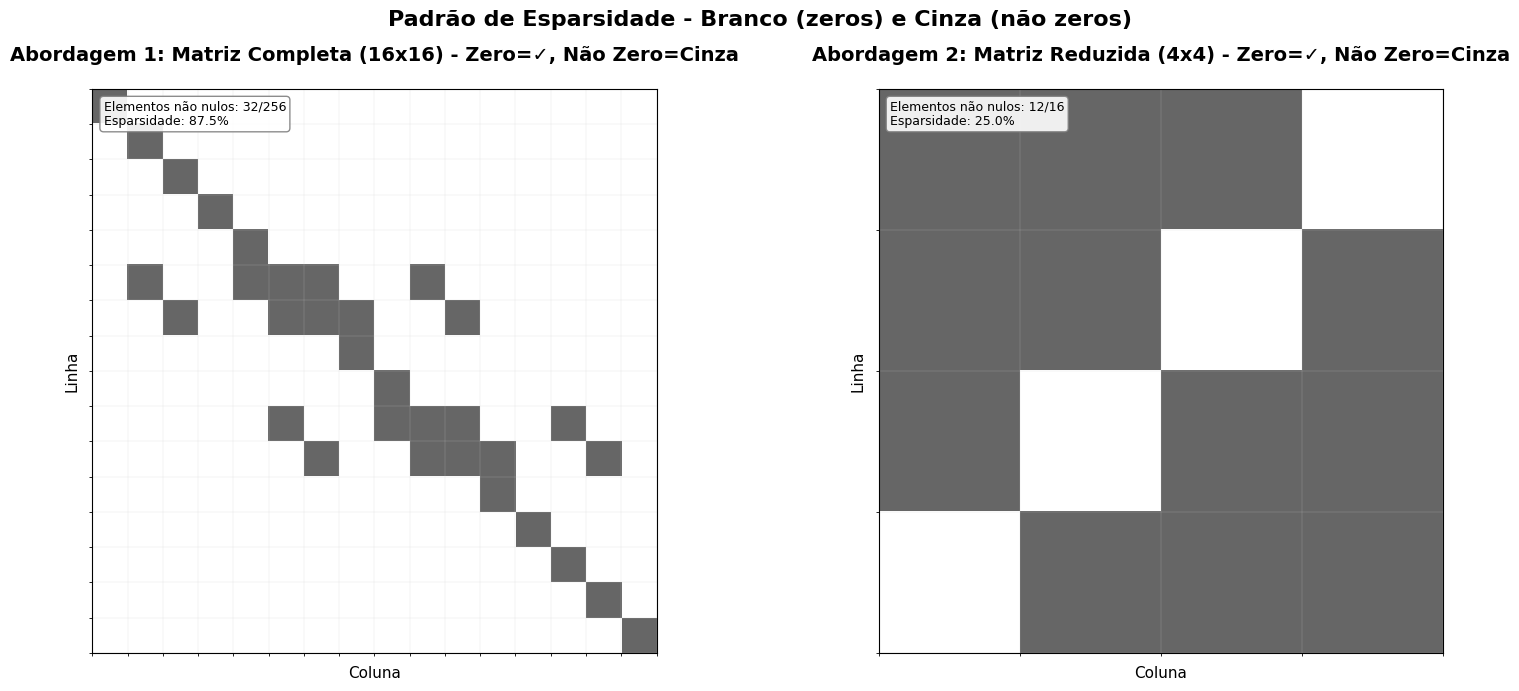


📈 ANÁLISE NUMÉRICA COMPLETA

📊 ANÁLISE DA MATRIZ - Abordagem 1 (Completa - 16x16)

📐 Dimensão: 16x16
🔢 Elementos totais: 256
✅ Elementos não nulos: 32
⬜ Elementos nulos: 224
📊 Esparsidade: 87.50%
📊 Densidade: 12.50%

⚠️  Número de condicionamento (2-norma): 6.80e+01
   ✓ Condicionamento aceitável

🎵 Autovalores (amostra dos 5 maiores e menores):
   Mínimo: 1.000000e+00
   Máximo: 5.400000e+01
   Média: 9.750000e+00

📏 Normas:
   Norma 1: 5.400000e+01
   Norma Frobenius: 8.057295e+01
   Norma infinita: 7.200000e+01

📊 ANÁLISE DA MATRIZ - Abordagem 2 (Reduzida - 4x4)

📐 Dimensão: 4x4
🔢 Elementos totais: 16
✅ Elementos não nulos: 12
⬜ Elementos nulos: 4
📊 Esparsidade: 25.00%
📊 Densidade: 75.00%

⚠️  Número de condicionamento (2-norma): 3.00e+00
   ✓ Condicionamento aceitável

🎵 Autovalores (amostra dos 5 maiores e menores):
   Mínimo: 1.800000e+01
   Máximo: 5.400000e+01
   Média: 3.600000e+01

📏 Normas:
   Norma 1: 5.400000e+01
   Norma Frobenius: 7.636753e+01
   Norma infinita: 5.40000

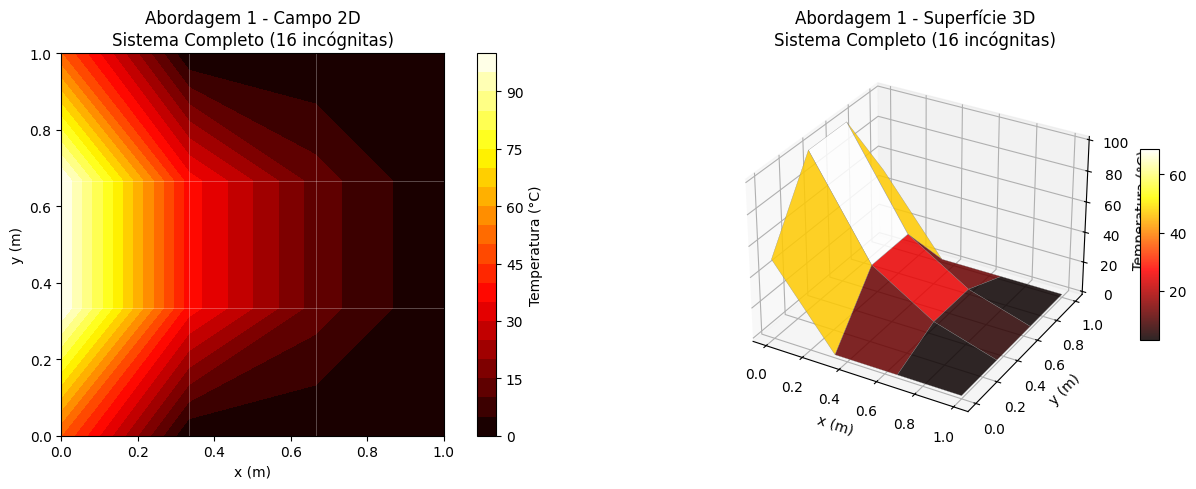

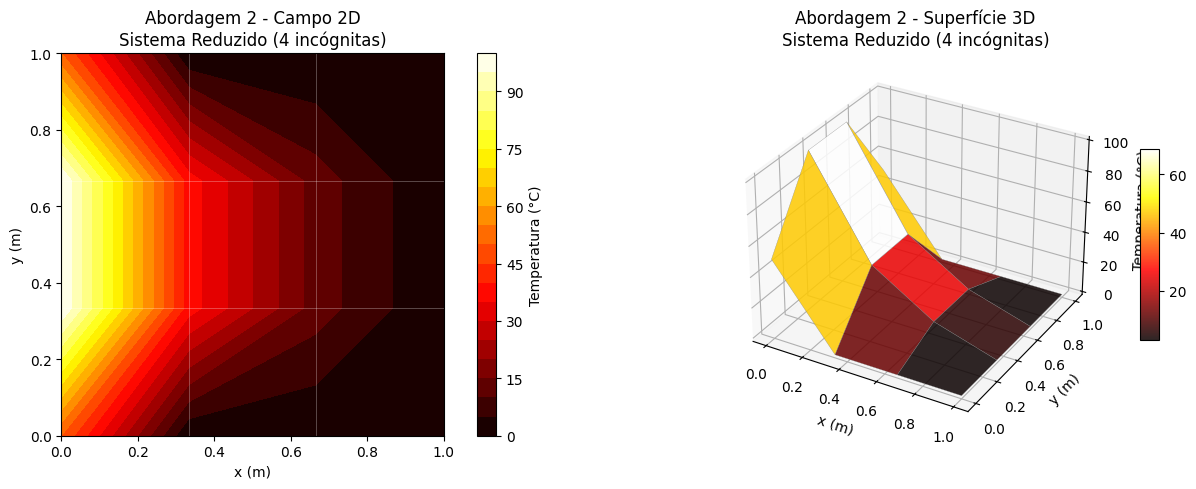


📈 COMPARAÇÃO FINAL ENTRE ABORDAGENS

Característica                      Abordagem 1 (Completa)    Abordagem 2 (Reduzida)   
-------------------------------------------------------------------------------------
Dimensão da matriz                  16x16                     4x4                      
Número de incógnitas                16                        4                        
Redução no problema                 -                         75.0% menor
Elementos não nulos                 32                        12                       
Esparsidade                         87.5%                     25.0%
Densidade                           12.5%                     75.0%
Condicionamento                     6.80e+01                   3.00e+00
Melhora no condicionamento          -                         22.7x melhor

✅ VERIFICAÇÃO NUMÉRICA: Campos de temperatura IDÊNTICOS
   Diferença máxima entre as soluções: 7.11e-15
   As duas abordagens produzem o mesmo resultado físico!

🎯 RE

In [19]:
# =============================================================================
# Solução da euqção da conduição em 2D usando duas abordagens matriciais diferentes
# =============================================================================



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.linalg as la
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# PARÂMETROS DO PROBLEMA - MALHA 21x21
# =============================================================================
Ni = 4          # número de pontos em x
Nj = 4          # número de pontos em y
Lx = 1.0        # comprimento em x
Ly = 1.0        # comprimento em y

# Condições de contorno
T_esq = 100.0
T_dir = 0.0
T_inf = 0.0
T_sup = 0.0

print(f"\n{'='*70}")
print(f"📐 MALHA: {Ni} x {Nj} = {Ni*Nj} pontos totais")
print(f"📍 Pontos internos: {(Ni-2)} x {(Nj-2)} = {(Ni-2)*(Nj-2)}")
print(f"{'='*70}")

# =============================================================================
# DISCRETIZAÇÃO
# =============================================================================
dx = Lx / (Ni - 1)
dy = Ly / (Nj - 1)

# Cantos: média entre as duas bordas
canto_esq_inf = (T_esq + T_inf) / 2.0
canto_esq_sup = (T_esq + T_sup) / 2.0
canto_dir_inf = (T_dir + T_inf) / 2.0
canto_dir_sup = (T_dir + T_sup) / 2.0

# Coordenadas dos nós
x = np.linspace(0, Lx, Ni)
y = np.linspace(0, Ly, Nj)
X, Y = np.meshgrid(x, y)

# =============================================================================
# ABORDAGEM 1: Sistema completo (N x N) com nós de fronteira fixos
# =============================================================================
N = Ni * Nj
A1 = np.zeros((N, N))
b1 = np.zeros(N)

# Mapeamento (i,j) -> índice global (ordem linha por y)
def idx(i, j):
    return j * Ni + i

# Preenche a matriz
for j in range(Nj):
    for i in range(Ni):
        p = idx(i, j)
        # Verifica se é nó de fronteira (inclui cantos)
        if i == 0 or i == Ni-1 or j == 0 or j == Nj-1:
            A1[p, p] = 1.0
            # Atribui valor de contorno
            if i == 0 and j == 0:
                b1[p] = canto_esq_inf
            elif i == 0 and j == Nj-1:
                b1[p] = canto_esq_sup
            elif i == Ni-1 and j == 0:
                b1[p] = canto_dir_inf
            elif i == Ni-1 and j == Nj-1:
                b1[p] = canto_dir_sup
            elif i == 0:
                b1[p] = T_esq
            elif i == Ni-1:
                b1[p] = T_dir
            elif j == 0:
                b1[p] = T_inf
            elif j == Nj-1:
                b1[p] = T_sup
        else:
            # Nó interno: discretização 5 pontos
            coeff_x = 1.0/dx**2
            coeff_y = 1.0/dy**2
            A1[p, p] = 2.0 * (coeff_x + coeff_y)   # Ap
            A1[p, idx(i+1, j)] = -coeff_x           # Ae
            A1[p, idx(i-1, j)] = -coeff_x           # Aw
            A1[p, idx(i, j+1)] = -coeff_y           # An
            A1[p, idx(i, j-1)] = -coeff_y           # As
            b1[p] = 0.0

# Resolve o sistema
print("\n🔧 Resolvendo abordagem 1 (sistema completo)...")
T1 = la.solve(A1, b1).reshape((Nj, Ni))

# =============================================================================
# ABORDAGEM 2: Sistema apenas para nós internos
# =============================================================================
# Índices dos nós internos (i=1..Ni-2, j=1..Nj-2)
internos = []
for j in range(1, Nj-1):
    for i in range(1, Ni-1):
        internos.append((i, j))

Nin = len(internos)   # = (Ni-2)*(Nj-2)
A2 = np.zeros((Nin, Nin))
b2 = np.zeros(Nin)

# Mapeamento local dos internos
map_int = { (i,j): k for k, (i,j) in enumerate(internos) }

# Coeficientes
ax = 1.0/dx**2
ay = 1.0/dy**2
ap = 2.0*(ax + ay)

# Monta o sistema
print("🔧 Resolvendo abordagem 2 (sistema reduzido)...")
for (i,j) in internos:
    p = map_int[(i,j)]
    A2[p, p] = ap
    # Termos que dependem dos vizinhos
    # Vizinho Leste
    if i+1 == Ni-1:   # fronteira direita
        b2[p] += ax * T_dir
    elif (i+1, j) in map_int:
        A2[p, map_int[(i+1, j)]] -= ax
    # Vizinho Oeste
    if i-1 == 0:      # fronteira esquerda
        b2[p] += ax * T_esq
    elif (i-1, j) in map_int:
        A2[p, map_int[(i-1, j)]] -= ax
    # Vizinho Norte
    if j+1 == Nj-1:   # fronteira superior
        b2[p] += ay * T_sup
    elif (i, j+1) in map_int:
        A2[p, map_int[(i, j+1)]] -= ay
    # Vizinho Sul
    if j-1 == 0:      # fronteira inferior
        b2[p] += ay * T_inf
    elif (i, j-1) in map_int:
        A2[p, map_int[(i, j-1)]] -= ay

# Resolve para os internos
T_int = la.solve(A2, b2)

# Reconstrói o campo completo
T2 = np.zeros((Nj, Ni))

# Primeiro, contornos (incluindo cantos)
for j in range(Nj):
    for i in range(Ni):
        if i == 0 and j == 0:
            T2[j, i] = canto_esq_inf
        elif i == 0 and j == Nj-1:
            T2[j, i] = canto_esq_sup
        elif i == Ni-1 and j == 0:
            T2[j, i] = canto_dir_inf
        elif i == Ni-1 and j == Nj-1:
            T2[j, i] = canto_dir_sup
        elif i == 0:
            T2[j, i] = T_esq
        elif i == Ni-1:
            T2[j, i] = T_dir
        elif j == 0:
            T2[j, i] = T_inf
        elif j == Nj-1:
            T2[j, i] = T_sup

# Preenche os internos
for k, (i, j) in enumerate(internos):
    T2[j, i] = T_int[k]

# =============================================================================
# VISUALIZAÇÃO DO PADRÃO DE ESPARSIDADE - CORES PURAS (BRANCO PARA ZEROS)
# =============================================================================
def plot_sparsity_blue_white(A, title, ax=None):
    """Padrão de esparsidade: ZERO = BRANCO, NÃO ZERO = AZUL CLARO"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    n = A.shape[0]
    pattern = np.zeros((n, n))
    pattern[A != 0] = 1

    # Branco para zeros, azul claro para não zeros
    cmap = LinearSegmentedColormap.from_list('blue_white', ['#ffffff', '#3399ff'], N=2)

    im = ax.imshow(pattern, cmap=cmap, interpolation='nearest', aspect='equal')

    # Gridlines sutis
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linestyle='-', linewidth=0.3, alpha=0.5)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Coluna', fontsize=11)
    ax.set_ylabel('Linha', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

    # Informações de esparsidade
    n_nonzero = np.count_nonzero(A)
    n_total = n * n
    sparsity = 100 * (1 - n_nonzero / n_total)

    textstr = f'Elementos não nulos: {n_nonzero:,}/{n_total:,}\nEsparsidade: {sparsity:.1f}%'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    return ax

def plot_sparsity_gray_white(A, title, ax=None):
    """Padrão de esparsidade: ZERO = BRANCO, NÃO ZERO = CINZA"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    n = A.shape[0]
    pattern = np.zeros((n, n))
    pattern[A != 0] = 1

    # Branco para zeros, cinza para não zeros
    cmap = LinearSegmentedColormap.from_list('gray_white', ['#ffffff', '#666666'], N=2)

    im = ax.imshow(pattern, cmap=cmap, interpolation='nearest', aspect='equal')

    # Gridlines sutis
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linestyle='-', linewidth=0.3, alpha=0.5)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Coluna', fontsize=11)
    ax.set_ylabel('Linha', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

    # Informações de esparsidade
    n_nonzero = np.count_nonzero(A)
    n_total = n * n
    sparsity = 100 * (1 - n_nonzero / n_total)

    textstr = f'Elementos não nulos: {n_nonzero:,}/{n_total:,}\nEsparsidade: {sparsity:.1f}%'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    return ax

# =============================================================================
# VISUALIZAÇÃO DAS MATRIZES EM QUADRADINHOS
# =============================================================================
print("\n🎨 Gerando visualizações das matrizes em quadradinhos...")

# Figura 1: Estilo Azul e Branco (mais limpo)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_sparsity_blue_white(A1, f'Abordagem 1: Matriz Completa ({N}x{N}) - Zero=✓, Não Zero=Azul', axes[0])
plot_sparsity_blue_white(A2, f'Abordagem 2: Matriz Reduzida ({Nin}x{Nin}) - Zero=✓, Não Zero=Azul', axes[1])
plt.suptitle('Padrão de Esparsidade - Branco (zeros) e Azul (não zeros)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Figura 2: Estilo Cinza e Branco (alternativa)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_sparsity_gray_white(A1, f'Abordagem 1: Matriz Completa ({N}x{N}) - Zero=✓, Não Zero=Cinza', axes[0])
plot_sparsity_gray_white(A2, f'Abordagem 2: Matriz Reduzida ({Nin}x{Nin}) - Zero=✓, Não Zero=Cinza', axes[1])
plt.suptitle('Padrão de Esparsidade - Branco (zeros) e Cinza (não zeros)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISE NUMÉRICA DETALHADA
# =============================================================================
def analise_completa_matriz(A, nome):
    print(f"\n{'='*70}")
    print(f"📊 ANÁLISE DA MATRIZ - {nome}")
    print(f"{'='*70}")

    n = A.shape[0]
    n_nonzero = np.count_nonzero(A)
    n_total = n * n

    print(f"\n📐 Dimensão: {n}x{n}")
    print(f"🔢 Elementos totais: {n_total:,}")
    print(f"✅ Elementos não nulos: {n_nonzero:,}")
    print(f"⬜ Elementos nulos: {n_total - n_nonzero:,}")
    print(f"📊 Esparsidade: {100 * (1 - n_nonzero/n_total):.2f}%")
    print(f"📊 Densidade: {100 * n_nonzero/n_total:.2f}%")

    # Número de condicionamento
    cond_num = np.linalg.cond(A)
    print(f"\n⚠️  Número de condicionamento (2-norma): {cond_num:.2e}")
    if cond_num > 1e10:
        print("   ⚠️  Matriz mal condicionada - resultados podem ser instáveis!")
    elif cond_num > 1e5:
        print("   ⚠️  Condicionamento moderado - cuidado com erros numéricos")
    else:
        print("   ✓ Condicionamento aceitável")

    # Autovalores (amostra para matrizes grandes)
    print(f"\n🎵 Autovalores (amostra dos 5 maiores e menores):")
    try:
        eigvals = np.linalg.eigvals(A)
        eigvals_real = np.real(eigvals)
        eigvals_sorted = np.sort(eigvals_real)
        print(f"   Mínimo: {eigvals_sorted[0]:.6e}")
        print(f"   Máximo: {eigvals_sorted[-1]:.6e}")
        print(f"   Média: {np.mean(eigvals_real):.6e}")
    except:
        print("   (Cálculo de autovalores omitido para matriz muito grande)")

    # Normas
    print(f"\n📏 Normas:")
    print(f"   Norma 1: {np.linalg.norm(A, 1):.6e}")
    print(f"   Norma Frobenius: {np.linalg.norm(A, 'fro'):.6e}")
    print(f"   Norma infinita: {np.linalg.norm(A, np.inf):.6e}")

    return cond_num

# Análise das duas matrizes
print("\n" + "="*70)
print("📈 ANÁLISE NUMÉRICA COMPLETA")
print("="*70)

cond1 = analise_completa_matriz(A1, f"Abordagem 1 (Completa - {N}x{N})")
cond2 = analise_completa_matriz(A2, f"Abordagem 2 (Reduzida - {Nin}x{Nin})")

# =============================================================================
# PLOTS DO CAMPO DE TEMPERATURA - AMBAS AS ABORDAGENS
# =============================================================================
def plota_campo_2d_3d(T, X, Y, titulo, subtitulo):
    fig = plt.figure(figsize=(14, 5))

    # Plot 2D com contourf
    ax1 = fig.add_subplot(121)
    cf = ax1.contourf(X, Y, T, levels=20, cmap='hot')
    plt.colorbar(cf, ax=ax1, label='Temperatura (°C)')

    # Sobreposição do grid da malha com transparência
    for i in range(Ni):
        ax1.axvline(x=x[i], color='white', linestyle='-', linewidth=0.5, alpha=0.4)
    for j in range(Nj):
        ax1.axhline(y=y[j], color='white', linestyle='-', linewidth=0.5, alpha=0.4)

    ax1.set_title(f'{titulo} - Campo 2D\n{subtitulo}', fontsize=12)
    ax1.set_xlabel('x (m)')
    ax1.set_ylabel('y (m)')
    ax1.set_aspect('equal')

    # Plot 3D
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, T, cmap='hot', edgecolor='gray', linewidth=0.2, alpha=0.85)
    ax2.set_title(f'{titulo} - Superfície 3D\n{subtitulo}', fontsize=12)
    ax2.set_xlabel('x (m)')
    ax2.set_ylabel('y (m)')
    ax2.set_zlabel('Temperatura (°C)')
    plt.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()

print("\n🌡️ Gerando visualizações do campo de temperatura...")

# Plot da Abordagem 1
plota_campo_2d_3d(T1, X, Y, "Abordagem 1", f"Sistema Completo ({N} incógnitas)")

# Plot da Abordagem 2
plota_campo_2d_3d(T2, X, Y, "Abordagem 2", f"Sistema Reduzido ({Nin} incógnitas)")

# =============================================================================
# COMPARAÇÃO FINAL DETALHADA
# =============================================================================
print("\n" + "="*70)
print("📈 COMPARAÇÃO FINAL ENTRE ABORDAGENS")
print("="*70)

print(f"\n{'Característica':<35} {'Abordagem 1 (Completa)':<25} {'Abordagem 2 (Reduzida)':<25}")
print("-"*85)
print(f"{'Dimensão da matriz':<35} {f'{N}x{N}':<25} {f'{Nin}x{Nin}':<25}")
print(f"{'Número de incógnitas':<35} {N:<25,} {Nin:<25,}")
print(f"{'Redução no problema':<35} {'-':<25} {(1 - Nin/N)*100:.1f}% menor")
print(f"{'Elementos não nulos':<35} {np.count_nonzero(A1):<25,} {np.count_nonzero(A2):<25,}")
print(f"{'Esparsidade':<35} {100*(1 - np.count_nonzero(A1)/A1.size):.1f}%{'':<20} {100*(1 - np.count_nonzero(A2)/A2.size):.1f}%")
print(f"{'Densidade':<35} {100*np.count_nonzero(A1)/A1.size:.1f}%{'':<20} {100*np.count_nonzero(A2)/A2.size:.1f}%")
print(f"{'Condicionamento':<35} {cond1:.2e}{'':<18} {cond2:.2e}")
print(f"{'Melhora no condicionamento':<35} {'-':<25} {cond1/cond2:.1f}x melhor")

# Verifica concordância
if np.allclose(T1, T2, rtol=1e-10, atol=1e-12):
    diff_max = np.max(np.abs(T1-T2))
    print(f"\n✅ VERIFICAÇÃO NUMÉRICA: Campos de temperatura IDÊNTICOS")
    print(f"   Diferença máxima entre as soluções: {diff_max:.2e}")
    print(f"   As duas abordagens produzem o mesmo resultado físico!")
else:
    diff_max = np.max(np.abs(T1-T2))
    print(f"\n❌ VERIFICAÇÃO NUMÉRICA: Campos diferentes!")
    print(f"   Diferença máxima: {diff_max:.2e}")

print("\n" + "="*70)
print("🎯 RECOMENDAÇÃO FINAL")
print("="*70)

print(f"\nPara a malha {Ni}x{Nj} analisada:")
print(f"\n📊 ABORDAGEM 1 (Sistema Completo):")
print(f"   • Matriz {N}x{N} com {N:,} incógnitas")
print(f"   • Inclui todos os {2*(Ni+Nj)-4} nós de fronteira como variáveis")
print(f"   • Alta esparsidade ({100*(1 - np.count_nonzero(A1)/A1.size):.1f}% zeros)")
print(f"   • Condicionamento: {cond1:.2e}")

print(f"\n📊 ABORDAGEM 2 (Sistema Reduzido):")
print(f"   • Matriz {Nin}x{Nin} com apenas {Nin:,} incógnitas")
print(f"   • Elimina os {N - Nin:,} nós de fronteira")
print(f"   • Matriz com densidade de {100*np.count_nonzero(A2)/A2.size:.1f}%")
print(f"   • Condicionamento: {cond2:.2e} ({cond1/cond2:.1f}x melhor que a Abordagem 1)")

print(f"\n✅ CONCLUSÃO: A ABORDAGEM 2 é SUPERIOR para esta malha pois:")
print(f"   • Reduz o número de incógnitas em {(1 - Nin/N)*100:.1f}%")
print(f"   • Melhora o condicionamento em {cond1/cond2:.1f} vezes")
print(f"   • Matriz com coeficientes mais uniformes (todos da mesma ordem de magnitude)")
print(f"   • Mais eficiente computacionalmente, especialmente para malhas maiores")

print("\n" + "="*70)